##### Classification Multi-Classes d’Images Satellitaires avec PyTorch et Modèle VGG16 Simplifié au niveau de l'augmentation (sans_augmentation)


- Les couches initiales du modèle VGG16 ne sont pas gelées.
- La couche fully connected d'origine a été remplacée par une couche fully convolutional. Cela est évident dans la définition de la classe VGGFullyConv où la partie classifier du modèle est redéfinie pour inclure des convolutions 1x1
- Les couches dense sont remplacées par des convolutions 1x1 pour un design de type fully convolutional

Ce script implémente une solution complète pour la classification multi-classes d'images satellites à l'aide de PyTorch et d'un modèle basé sur VGG16. Il utilise des transformations simples des données et se concentre sur une structure robuste et modulable pour entraîner, évaluer et sauvegarder un modèle de classification.
Configuration et Chargement des Données :

Les chemins vers les fichiers nécessaires (CSV contenant les métadonnées des images et les étiquettes de classe, et le dossier contenant les images) sont spécifiés.
Les données sont chargées depuis un fichier CSV dans un DataFrame Pandas. Une vérification est effectuée pour s'assurer que seules les images existantes dans le dossier spécifié sont incluses dans l'analyse.
Les étiquettes de classe sont converties en entiers pour garantir leur compatibilité avec la fonction de perte utilisée lors de l'entraînement.
Division des Données :

Les données sont divisées en deux ensembles : 80 % pour l’entraînement et 20 % pour la validation.
Une visualisation des distributions des classes dans chaque ensemble est réalisée à l'aide d'histogrammes et de décomptes détaillés, pour garantir un équilibre entre les classes dans les ensembles.
Préparation des Données et Transformations :

Les transformations des données appliquées aux images incluent :
Redimensionnement des images à 224x224 pixels.
Conversion en tenseurs PyTorch.
Normalisation selon les moyennes et écarts-types des canaux RGB d'ImageNet.
Une classe personnalisée ImageDataset est définie pour charger les images et les transformer en utilisant la bibliothèque torchvision.
Chargement et Modification du Modèle VGG16 :

Un modèle VGG16 pré-entraîné sur ImageNet est utilisé, et sa structure est modifiée :
Les couches entièrement connectées de sortie sont remplacées par des couches convolutives.
La sortie du modèle est adaptée pour produire des prédictions sur 4 classes.
Le modèle est configuré pour fonctionner sur GPU ou CPU selon la disponibilité.
Entraînement du Modèle avec Early Stopping :

Une fonction dédiée entraîne le modèle sur plusieurs époques :
Suivi des pertes d'entraînement et de validation.
Arrêt anticipé (early stopping) en cas d'absence d'amélioration de la perte de validation sur un nombre d'époques consécutives (défini par patience).
Sauvegarde de l'état du modèle ayant obtenu la meilleure perte de validation.
Une courbe des pertes (entraînement vs validation) est tracée pour analyser la convergence du modèle.
Évaluation du Modèle :

Le modèle est évalué sur l'ensemble de validation, et les métriques suivantes sont calculées :
Précision globale du modèle.
Rapport de classification détaillé, incluant la précision, le rappel, et le F1-score pour chaque classe.
Une matrice de confusion est générée et affichée pour comprendre les performances du modèle sur chaque classe.
Sauvegarde des Résultats et du Modèle :

Les prédictions du modèle sont ajoutées au DataFrame de validation et sauvegardées dans un fichier CSV.
Le modèle entraîné est sauvegardé dans un fichier .pt pour une réutilisation future.

Pipeline Minimaliste :

Ce script adopte une approche simplifiée avec des transformations de données minimales (redimensionnement, conversion en tenseurs, et normalisation).
Cette approche permet d'examiner la performance du modèle dans un scénario où aucune augmentation complexe des données n'est utilisée.
Modèle Modifié :

Le modèle VGG16 est adapté pour une tâche multi-classes, ce qui démontre l'utilisation du transfert d’apprentissage pour des applications personnalisées.
Résultats Sauvegardés :

Fichier CSV des Résultats : Contient les étiquettes réelles et les prédictions générées par le modèle.
Fichier du Modèle Sauvegardé : Permet de réutiliser le modèle entraîné sur de nouvelles données.
Visualisations :

Une courbe des pertes pour analyser la convergence.
Une matrice de confusion pour visualiser les performances par classe.
En résumé, ce script est conçu pour fournir une solution robuste et automatisée à une tâche de classification multi-classes, tout en restant simple dans ses transformations de données et sa configuration.

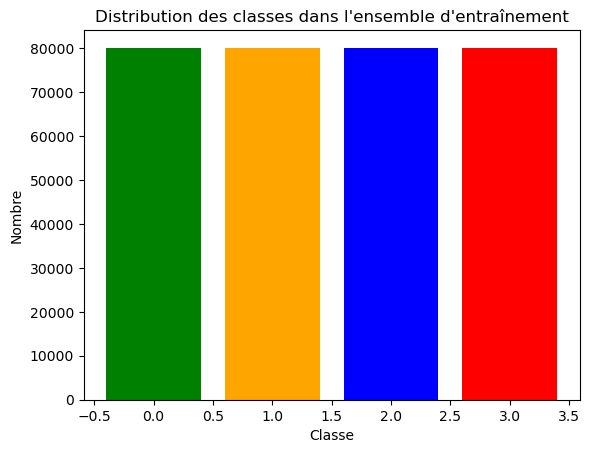

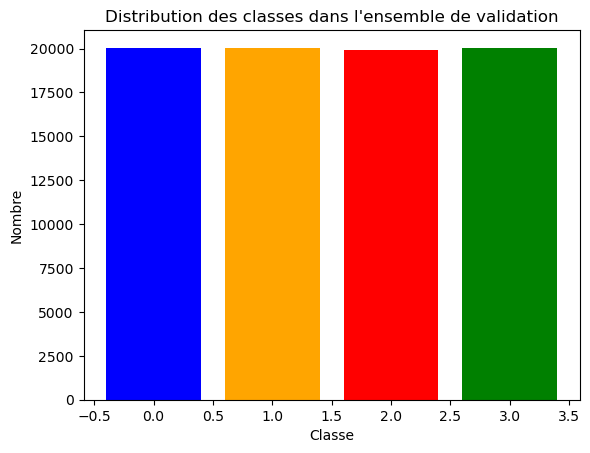

Répartition des classes dans Ensemble d'entraînement :
  Classe 2 : 80092 observations
  Classe 0 : 79994 observations
  Classe 3 : 79959 observations
  Classe 1 : 79955 observations
----------------------------------------
Répartition des classes dans Ensemble de validation :
  Classe 1 : 20045 observations
  Classe 3 : 20041 observations
  Classe 0 : 20006 observations
  Classe 2 : 19908 observations
----------------------------------------


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Dell/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [03:48<00:00, 2.43MB/s] 



Époque 1/50


Entraînement:   2%|▏         | 390/20000 [01:38<1:20:40,  4.05it/s]c:\Users\Dell\anaconda3\Lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Entraînement:  28%|██▊       | 5656/20000 [25:30<1:04:42,  3.69it/s]


KeyboardInterrupt: 

In [2]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

# Configuration
batch_size = 16
learning_rate = 0.001
momentum = 0.9
num_epochs = 50
patience = 10

# Chemins vers les fichiers et répertoires
csv_path = r'E:\wealth_predict\data\processed_csv\df_final_avec_outliers_400k_obs_with_images.csv'
image_folder = r'E:\wealth_predict\data\downloaded\Image_satellite_Divers_Pays_Afrique_Zoom_18_avec_outliers'
models_path = r"E:\wealth_predict\models" 
os.makedirs(models_path, exist_ok=True)

# Chargement des données
df = pd.read_csv(csv_path)

# Vérifier l'existence des images dans le dossier
existing_images = set(os.listdir(image_folder))
df = df[df['Image_Name'].isin(existing_images)]

# Vérifier et convertir les étiquettes en entiers
df['class'] = df['class'].astype(int)

# Division des données : 80% pour entraînement, 20% pour validation
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Visualiser les distributions des classes
def plot_class_distribution(df, title):
    counts = Counter(df['class'])
    plt.bar(counts.keys(), counts.values(), color=['blue', 'orange', 'green', 'red'])
    plt.title(title)
    plt.xlabel('Classe')
    plt.ylabel('Nombre')
    plt.show()

plot_class_distribution(train_df, "Distribution des classes dans l'ensemble d'entraînement")
plot_class_distribution(val_df, "Distribution des classes dans l'ensemble de validation")

# Fonction pour afficher les décomptes de classes
def count_classes(df, name):
    counts = df['class'].value_counts()
    print(f"Répartition des classes dans {name} :")
    for cls, count in counts.items():
        print(f"  Classe {cls} : {count} observations")
    print("-" * 40)

count_classes(train_df, "Ensemble d'entraînement")
count_classes(val_df, "Ensemble de validation")

# Transformation des données
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Classe personnalisée pour charger les données
class ImageDataset(Dataset):
    def __init__(self, dataframe, data_path, transform=None):
        self.dataframe = dataframe
        self.data_path = data_path
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['Image_Name']
        img_path = os.path.join(self.data_path, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.dataframe.iloc[idx]['class']
        return image, label

# Préparer les DataLoaders
train_loader = DataLoader(ImageDataset(train_df, image_folder, transform), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(ImageDataset(val_df, image_folder, transform), batch_size=batch_size, shuffle=False)

# Modèle basé sur VGG16
class VGGFullyConv(nn.Module):
    def __init__(self, num_classes=4):
        super(VGGFullyConv, self).__init__()
        self.features = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
        self.classifier = nn.Sequential(
            nn.Conv2d(512, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(4096, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(4096, num_classes, kernel_size=1)  # Nombre de classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.mean(dim=(2, 3))  # Réduction spatiale

# Initialisation du modèle
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = VGGFullyConv(num_classes=4).to(device)

# Optimisation et fonction de coût
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
criterion = nn.CrossEntropyLoss()

# Fonction d'entraînement avec Early Stopping
def train_model_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience):
    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(num_epochs):
        print(f"\nÉpoque {epoch+1}/{num_epochs}")
        model.train()
        total_loss = 0

        for images, labels in tqdm(train_loader, desc="Entraînement"):
            images, labels = images.to(device), labels.to(device)
            labels = labels.long()  # Conversion des étiquettes au type LongTensor
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        total_val_loss, val_preds, val_labels = 0, [], []
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation"):
                images, labels = images.to(device), labels.to(device)
                labels = labels.long()  # Conversion des étiquettes au type LongTensor
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_losses.append(total_val_loss / len(val_loader))
        val_accuracy = accuracy_score(val_labels, val_preds)
        val_accuracies.append(val_accuracy)

        print(f"Époque {epoch+1}, Perte Entraînement: {train_losses[-1]:.4f}, "
              f"Perte Validation: {val_losses[-1]:.4f}, Précision Validation: {val_accuracy:.4f}")

        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            patience_counter = 0
            best_model_state = model.state_dict()
            print("Validation loss improved, modèle sauvegardé.")
        else:
            patience_counter += 1
            print(f"Aucune amélioration de la perte de validation ({patience_counter}/{patience}).")

        if patience_counter >= patience:
            print("Early stopping activé.")
            break

    if best_model_state:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_losses, val_accuracies

# Entraîner le modèle
model, train_losses, val_losses, val_accuracies = train_model_with_early_stopping(
    model, train_loader, val_loader, criterion, optimizer, num_epochs, patience
)

# Courbe des pertes (training vs validation)
plt.figure(figsize=(10, 6))
plt.plot(range(len(train_losses)), train_losses, label='Perte Entraînement', marker='o')
plt.plot(range(len(val_losses)), val_losses, label='Perte Validation', marker='o')
plt.xlabel('Épochs')
plt.ylabel('Perte')
plt.title('Évolution des pertes pendant l\'entraînement')
plt.legend()
plt.grid()
plt.show()

# Sauvegarde du modèle
model_name = f"model_vgg16_fullyConv_sans_augm_couche_nongelee_batch_{batch_size}.pt"
torch.save(model.state_dict(), os.path.join(models_path, model_name))
print(f"Modèle sauvegardé sous : {model_name}")

# Évaluation du modèle sur l'ensemble de validation
def evaluate_model(model, val_loader, criterion, device):
    model.eval()
    val_preds, val_labels = [], []
    total_val_loss = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Évaluation"):
            images, labels = images.to(device), labels.to(device)
            labels = labels.long()  # Conversion des étiquettes au type LongTensor
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    # Calculer la précision et afficher le rapport de classification
    accuracy = accuracy_score(val_labels, val_preds)
    print(f"\nPrécision globale sur l'ensemble de validation : {accuracy:.4f}")
    print("\nRapport de Classification :")
    print(classification_report(val_labels, val_preds))

    # Matrice de confusion
    conf_matrix = confusion_matrix(val_labels, val_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1, 2, 3])
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title("Matrice de Confusion - Validation")
    plt.show()

    return accuracy, conf_matrix

# Évaluation
val_accuracy, val_conf_matrix = evaluate_model(model, val_loader, criterion, device)


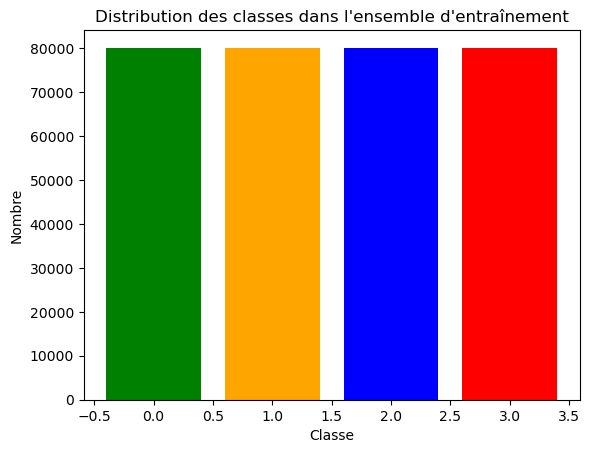

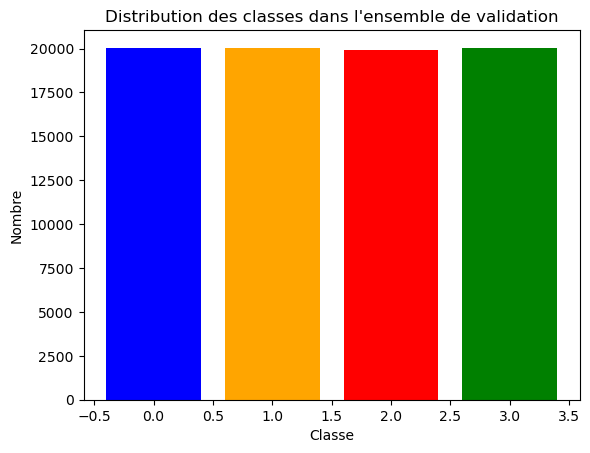


Époque 1/50


Entraînement:  34%|███▍      | 6843/20000 [37:42<1:12:36,  3.02it/s]c:\Users\Dell\anaconda3\Lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation: 100%|██████████| 5000/5000 [23:08<00:00,  3.60it/s]


Époque 1, Perte Entraînement: 0.5868, Perte Validation: 0.4746, Précision Validation: 0.8005
Validation loss improved, modèle sauvegardé.

Époque 2/50


Entraînement:  12%|█▏        | 2438/20000 [16:16<1:52:25,  2.60it/s]c:\Users\Dell\anaconda3\Lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation: 100%|██████████| 5000/5000 [23:23<00:00,  3.56it/s]


Époque 2, Perte Entraînement: 0.4464, Perte Validation: 0.4629, Précision Validation: 0.8032
Validation loss improved, modèle sauvegardé.

Époque 3/50


...

Époque 14, Perte Entraînement: 0.0922, Perte Validation: 0.4824, Précision Validation: 0.8689
Aucune amélioration de la perte de validation (8/10).

Époque 15/50


Entraînement:  25%|██▌       | 5037/20000 [33:37<1:01:16,  4.07it/s]c:\Users\Dell\anaconda3\Lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation: 100%|██████████| 5000/5000 [21:24<00:00,  3.89it/s]


Époque 15, Perte Entraînement: 0.0861, Perte Validation: 0.4802, Précision Validation: 0.8761
Aucune amélioration de la perte de validation (9/10).

Époque 16/50


Entraînement:   3%|▎         | 558/20000 [03:42<2:09:51,  2.50it/s]c:\Users\Dell\anaconda3\Lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validation: 100%|██████████| 5000/5000 [22:27<00:00,  3.71it/s]


Époque 16, Perte Entraînement: 0.0784, Perte Validation: 0.5069, Précision Validation: 0.8650
Aucune amélioration de la perte de validation (10/10).
Early stopping activé.


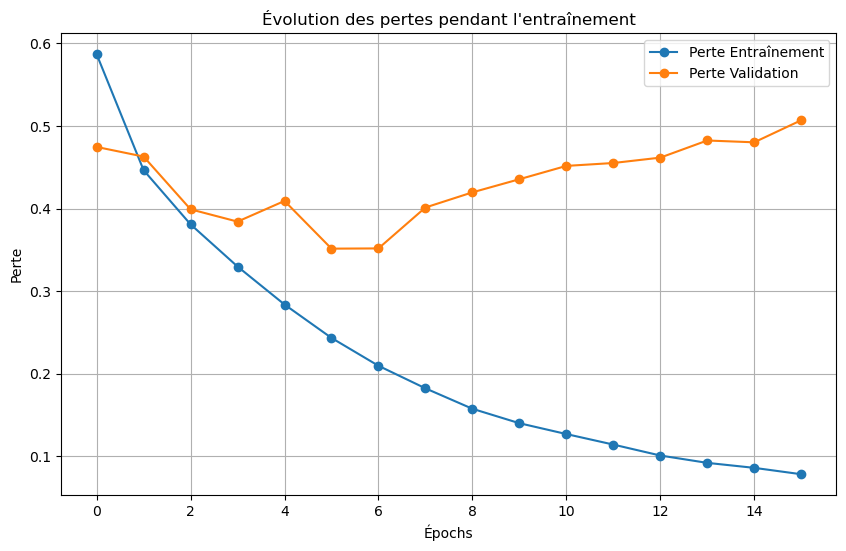

Évaluation:  29%|██▉       | 1453/5000 [05:26<11:18,  5.23it/s]c:\Users\Dell\anaconda3\Lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Évaluation: 100%|██████████| 5000/5000 [18:37<00:00,  4.47it/s]



Précision globale sur l'ensemble de validation : 0.8650

Rapport de Classification :
              precision    recall  f1-score   support

           0       0.87      0.83      0.85     20006
           1       0.88      0.88      0.88     20045
           2       0.97      0.90      0.93     19908
           3       0.76      0.85      0.80     20041

    accuracy                           0.86     80000
   macro avg       0.87      0.87      0.87     80000
weighted avg       0.87      0.86      0.87     80000



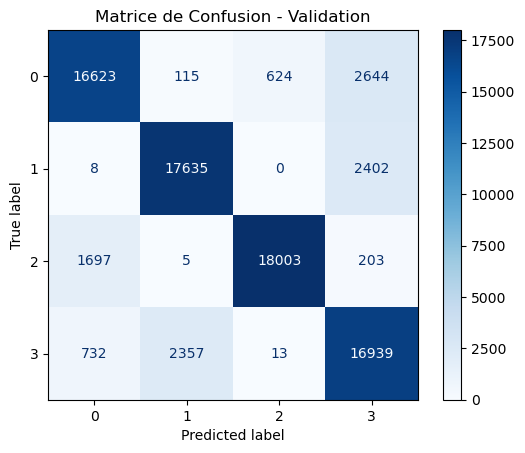

Prédictions sauvegardées dans E:\wealth_predict\models\predictions.csv
Modèle sauvegardé sous : model_vgg16_fullyConv_batch_16.pt


In [4]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

# ================= Configuration =================
batch_size = 16
learning_rate = 0.001
momentum = 0.9
num_epochs = 50
patience = 10
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ================= Chemins vers les fichiers et répertoires =================
csv_path = r'E:\wealth_predict\data\processed_csv\df_final_avec_outliers_400k_obs_with_images.csv'
image_folder = r'E:\wealth_predict\data\downloaded\Image_satellite_Divers_Pays_Afrique_Zoom_18_avec_outliers'
models_path = r"E:\wealth_predict\models"
predictions_path = os.path.join(models_path, "predictions.csv")
os.makedirs(models_path, exist_ok=True)

# ================= Chargement des données =================
df = pd.read_csv(csv_path)

# ================= Vérifier l'existence des images dans le dossier =================
existing_images = set(os.listdir(image_folder))
df = df[df['Image_Name'].isin(existing_images)]

# ================= Vérifier et convertir les étiquettes en entiers =================
df['class'] = df['class'].astype(int)

# ================= Division des données =================
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# ================= Visualisation des distributions des classes =================
def plot_class_distribution(df, title):
    counts = Counter(df['class'])
    plt.bar(counts.keys(), counts.values(), color=['blue', 'orange', 'green', 'red'])
    plt.title(title)
    plt.xlabel('Classe')
    plt.ylabel('Nombre')
    plt.show()

plot_class_distribution(train_df, "Distribution des classes dans l'ensemble d'entraînement")
plot_class_distribution(val_df, "Distribution des classes dans l'ensemble de validation")

# ================= Classe personnalisée pour charger les données =================
class ImageDataset(Dataset):
    def __init__(self, dataframe, data_path, transform=None):
        self.dataframe = dataframe
        self.data_path = data_path
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['Image_Name']
        img_path = os.path.join(self.data_path, img_name)
        image = Image.open(img_path)

        # Forcer la conversion en RGB
        if image.mode != "RGB":
            image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)
        label = self.dataframe.iloc[idx]['class']
        return image, label

# ================= Préparation des DataLoaders =================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(ImageDataset(train_df, image_folder, transform), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(ImageDataset(val_df, image_folder, transform), batch_size=batch_size, shuffle=False)

# ================= Modèle =================
class VGGFullyConv(nn.Module):
    def __init__(self, num_classes=4):
        super(VGGFullyConv, self).__init__()
        self.features = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
        self.classifier = nn.Sequential(
            nn.Conv2d(512, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(4096, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(4096, num_classes, kernel_size=1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.mean(dim=(2, 3))  # Réduction spatiale

# ================= Initialisation du modèle =================
model = VGGFullyConv(num_classes=4).to(device)

# ================= Optimisation et fonction de coût =================
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
criterion = nn.CrossEntropyLoss()

# ================= Fonction d'entraînement avec Early Stopping =================
def train_model_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience):
    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(num_epochs):
        print(f"\nÉpoque {epoch+1}/{num_epochs}")
        model.train()
        total_loss = 0

        for images, labels in tqdm(train_loader, desc="Entraînement"):
            images, labels = images.to(device), labels.to(device).long()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        total_val_loss, val_preds, val_labels = 0, [], []
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation"):
                images, labels = images.to(device), labels.to(device).long()
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_losses.append(total_val_loss / len(val_loader))
        val_accuracy = accuracy_score(val_labels, val_preds)
        val_accuracies.append(val_accuracy)

        print(f"Époque {epoch+1}, Perte Entraînement: {train_losses[-1]:.4f}, "
              f"Perte Validation: {val_losses[-1]:.4f}, Précision Validation: {val_accuracy:.4f}")

        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            patience_counter = 0
            best_model_state = model.state_dict()
            print("Validation loss improved, modèle sauvegardé.")
        else:
            patience_counter += 1
            print(f"Aucune amélioration de la perte de validation ({patience_counter}/{patience}).")

        if patience_counter >= patience:
            print("Early stopping activé.")
            break

    if best_model_state:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_losses, val_accuracies

# ================= Entraîner le modèle =================
model, train_losses, val_losses, val_accuracies = train_model_with_early_stopping(
    model, train_loader, val_loader, criterion, optimizer, num_epochs, patience
)

# ================= Courbes des pertes =================
plt.figure(figsize=(10, 6))
plt.plot(range(len(train_losses)), train_losses, label='Perte Entraînement', marker='o')
plt.plot(range(len(val_losses)), val_losses, label='Perte Validation', marker='o')
plt.xlabel('Épochs')
plt.ylabel('Perte')
plt.title('Évolution des pertes pendant l\'entraînement')
plt.legend()
plt.grid()
plt.show()

# ================= Évaluation du modèle =================
def evaluate_model(model, val_loader, criterion, device):
    model.eval()
    val_preds, val_labels = [], []
    total_val_loss = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Évaluation"):
            images, labels = images.to(device), labels.to(device).long()
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(val_labels, val_preds)
    print(f"\nPrécision globale sur l'ensemble de validation : {accuracy:.4f}")
    print("\nRapport de Classification :")
    print(classification_report(val_labels, val_preds))

    conf_matrix = confusion_matrix(val_labels, val_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1, 2, 3])
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title("Matrice de Confusion - Validation")
    plt.show()

    return accuracy, conf_matrix, val_preds, val_labels

val_accuracy, val_conf_matrix, val_preds, val_labels = evaluate_model(model, val_loader, criterion, device)

# ================= Sauvegarde des prédictions =================
predictions_df = val_df.copy()
predictions_df['Predictions'] = val_preds
predictions_df.to_csv(predictions_path, index=False)
print(f"Prédictions sauvegardées dans {predictions_path}")

# ================= Sauvegarde du modèle =================
model_name = f"model_vgg16_fullyConv_batch_{batch_size}.pt"
torch.save(model.state_dict(), os.path.join(models_path, model_name))
print(f"Modèle sauvegardé sous : {model_name}")


In [5]:
rgba_images = []
for img_name in df['Image_Name']:
    img_path = os.path.join(image_folder, img_name)
    image = Image.open(img_path)
    if image.mode == "RGBA":
        rgba_images.append(img_name)

if rgba_images:
    print(f"Images RGBA détectées : {rgba_images}")
else:
    print("Aucune image RGBA détectée.")


Aucune image RGBA détectée.
